# Recommendation Evaluation with MobileNetV3 Style Classifier

## 1. Objective

The objective of this notebook is to test the full recommendation pipeline using the MobileNetV3 Large style classifier.

The previous architecture comparison experiment showed that MobileNetV3 Large achieved the best real-world style classification result among the tested architectures. It achieved a real-world accuracy of **0.6250** and a real-world macro F1-score of **0.6242**, outperforming both ResNet34 and EfficientNet-B0.

However, better classification performance does not automatically mean better recommendation quality. The recommendation system depends on the style classifier, but it also depends on the clothing type classifier, the recommendation catalogue, the embedding-based ranking method, and the confidence safeguard logic.

Because of this, the MobileNetV3 Large style classifier needs to be tested inside the full recommendation pipeline before it can replace the current ResNet34-based style model.

The main research question for this experiment is:

_Does the MobileNetV3 Large style classifier improve recommendation quality compared with the previous ResNet34-based style classifier?_

## 2. Project Context

The current recommendation prototype uses image classification and embedding-based retrieval to recommend outfit items.

The recommendation process follows these steps:

1. Predict the style of the input image.
2. Predict the clothing type of the input image.
3. Filter the catalogue to items with the same predicted style.
4. Exclude items with the same predicted clothing type.
5. Rank the remaining candidate items using cosine similarity between image embeddings.
6. Return one recommended item per remaining clothing type.

Previous recommendation evaluations showed that the system is structurally reliable, but still limited by style prediction errors. The current recommendation evaluation framework showed strong structural validity, but weaker style consistency, visual coherence, and overall recommendation quality.

The current baseline recommendation evaluation used:

- `style_resnet34_extra_data.pth`
- `type_resnet34_extra_data.pth`
- ResNet34 image embeddings
- cosine similarity ranking
- confidence safeguards

This experiment changes only the style classifier. The rest of the pipeline stays the same.

The new setup uses:

- `style_mobilenet_v3_large_architecture_comparison.pth`
- `type_resnet34_extra_data.pth`
- ResNet34 image embeddings
- cosine similarity ranking
- confidence safeguards

This controlled setup makes it possible to check whether changing the style classifier improves the recommendation output.

## 3. Why This Experiment Is Needed

This experiment is needed because the architecture comparison only evaluated style classification performance.

MobileNetV3 Large performed better than ResNet34 on the real-world style classification test set, but the final project goal is not only classification. The final goal is to generate useful outfit recommendations.

A style classifier can improve standalone accuracy but still fail to improve recommendation quality. For example, it may correctly classify more images overall, but still make mistakes on the specific examples used in the recommendation evaluation. It may also produce different confidence scores, which can affect the confidence safeguard system.

Therefore, this experiment checks whether the improved style classifier also improves the user-facing recommendation pipeline.

This experiment should answer the following questions:

- Does MobileNetV3 Large improve style prediction accuracy on the 32-example recommendation evaluation subset?
- Does it improve style consistency in the recommended outfits?
- Does it improve visual coherence?
- Does it reduce bad recommendations?
- Does it change confidence safeguard behaviour?
- Should MobileNetV3 Large replace the current ResNet34 style model in the prototype?

## 4. Approach

This experiment uses the same recommendation evaluation framework as the previous 32-example evaluation.

The main difference is that the style classifier is replaced with the MobileNetV3 Large model from the architecture comparison experiment.

The experiment follows these steps:

1. Load the MobileNetV3 Large style classifier.
2. Load the improved ResNet34 clothing type classifier.
3. Load the cleaned recommendation catalogue.
4. Generate or load ResNet34 image embeddings for the catalogue.
5. Load the same 32 real-world evaluation examples.
6. Predict style and clothing type for each input image.
7. Apply confidence safeguards using the same thresholds as before.
8. Generate recommendations using the same filtering and embedding similarity logic.
9. Record automatic evaluation results.
10. Manually score the recommendation results using the same criteria as the previous evaluation.
11. Compare the results with the previous ResNet34-based recommendation evaluation.

The style classifier is the only major component changed in this experiment. This makes the comparison fair and helps isolate the effect of the MobileNetV3 Large model.

## 5. Experiment Design

The experiment is designed as a controlled pipeline comparison.

The previous recommendation evaluation used the dataset-improved ResNet34 style classifier. This experiment replaces it with the MobileNetV3 Large style classifier while keeping the rest of the system unchanged.

| Component | Previous setup | New setup |
|---|---|---|
| Style classifier | `style_resnet34_extra_data.pth` | `style_mobilenet_v3_large_architecture_comparison.pth` |
| Type classifier | `type_resnet34_extra_data.pth` | `type_resnet34_extra_data.pth` |
| Catalogue | `dataset/cleaned` | `dataset/cleaned` |
| Embedding extractor | ResNet34 | ResNet34 |
| Ranking method | Cosine similarity | Cosine similarity |
| Confidence thresholds | 0.60 style, 0.60 type | 0.60 style, 0.60 type |
| Evaluation subset | 32 balanced real-world examples | Same 32 balanced real-world examples |

The previous evaluation results are used as the baseline:

| Criterion | Previous score |
|---|---:|
| Structural validity | 1.8750 |
| Style consistency | 1.3125 |
| Visual coherence | 1.3125 |
| Confidence warning usefulness | 1.4688 |
| Overall quality | 1.3125 |

The goal is to check whether the MobileNetV3 Large style model improves these scores, especially style consistency, visual coherence, and overall quality.

## 6. Import Libraries

This notebook uses PyTorch and torchvision to load the trained classifiers and extract image embeddings.

Pandas and NumPy are used to store recommendation results. Matplotlib is used to visualize the input image and recommended items. Scikit-learn is used for cosine similarity and evaluation metrics.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import models, transforms
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

torch version: 2.11.0+cu130
cuda available: True
cuda device count: 1
gpu name: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: CUDA


## 7. Paths and Results Folder

This experiment uses the MobileNetV3 Large style classifier from the architecture comparison experiment.

The improved ResNet34 type classifier is kept the same as in the previous recommendation evaluation. The cleaned dataset is used as the recommendation catalogue, and the real-world test set is used for evaluation examples.

A separate results folder is created for this experiment.

In [2]:
style_model_path = "../models/style_mobilenet_v3_large_architecture_comparison.pth"
type_model_path = "../models/type_resnet34_extra_data.pth"

catalogue_root = "../dataset/cleaned"
real_world_dir = "../dataset/real_world_test"

results_dir = "../results/recommendation_mobilenet_style_model"
os.makedirs(results_dir, exist_ok=True)

print("Style model path:", style_model_path)
print("Type model path:", type_model_path)
print("Catalogue path:", catalogue_root)
print("Real-world test path:", real_world_dir)
print("Results folder:", results_dir)

print("Style model exists:", os.path.exists(style_model_path))
print("Type model exists:", os.path.exists(type_model_path))
print("Catalogue exists:", os.path.exists(catalogue_root))
print("Real-world test exists:", os.path.exists(real_world_dir))

Style model path: ../models/style_mobilenet_v3_large_architecture_comparison.pth
Type model path: ../models/type_resnet34_extra_data.pth
Catalogue path: ../dataset/cleaned
Real-world test path: ../dataset/real_world_test
Results folder: ../results/recommendation_mobilenet_style_model
Style model exists: True
Type model exists: True
Catalogue exists: True
Real-world test exists: True


## 8. Image Transform

The same image preprocessing is used for classification and embedding extraction.

Images are resized to 224 by 224 pixels, converted to tensors, and normalized using ImageNet mean and standard deviation values.

In [3]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 9. Load Models

This experiment uses two classifiers:

- MobileNetV3 Large for style classification
- ResNet34 for clothing type classification

The MobileNetV3 Large model is loaded from the architecture comparison experiment. The improved ResNet34 type classifier is reused from the previous recommendation evaluation.

A ResNet34 feature extractor is also loaded for image embeddings. This keeps the recommendation ranking method unchanged from the previous experiment.

In [4]:
style_checkpoint = torch.load(
    style_model_path,
    map_location=device,
    weights_only=False
)

type_checkpoint = torch.load(
    type_model_path,
    map_location=device,
    weights_only=False
)

style_class_names = style_checkpoint["class_names"]
type_class_names = type_checkpoint["class_names"]

print("Style classes:", style_class_names)
print("Type classes:", type_class_names)

Style classes: ['formal', 'gothic', 'sporty', 'streetwear']
Type classes: ['jacket', 'pants', 'shoes', 'tshirt']


In [5]:
def load_mobilenet_v3_style_classifier(checkpoint, num_classes):
    model = models.mobilenet_v3_large(weights=None)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    return model


def load_resnet34_classifier(checkpoint, num_classes):
    model = models.resnet34(weights=None)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    return model

In [6]:
style_model = load_mobilenet_v3_style_classifier(
    style_checkpoint,
    len(style_class_names)
)

type_model = load_resnet34_classifier(
    type_checkpoint,
    len(type_class_names)
)

print("MobileNetV3 style model loaded successfully.")
print("Improved ResNet34 type model loaded successfully.")

MobileNetV3 style model loaded successfully.
Improved ResNet34 type model loaded successfully.


### 9.1. Create Feature Extractor

The recommendation system still uses a ResNet34 feature extractor to generate image embeddings.

This is kept unchanged so that the experiment only tests the effect of replacing the style classifier.

In [7]:
resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

feature_extractor = nn.Sequential(*list(resnet.children())[:-1])

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("ResNet34 feature extractor ready.")

ResNet34 feature extractor ready.


### 9.2. Embedding Function

This helper function converts an image into a normalized feature vector using the ResNet34 feature extractor.

The normalized embedding is used later for cosine similarity ranking.

In [8]:
def get_image_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = image_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = feature_extractor(input_tensor)
        features = features.view(features.size(0), -1)
        features = F.normalize(features, p=2, dim=1)

    return features.cpu().numpy()[0]

## 10. Build Catalogue with Embeddings

The recommendation catalogue is built from the cleaned dataset.

Each catalogue item stores:

- image path
- known style
- known clothing type
- filename
- embedding index

The catalogue uses the `cleaned` dataset because this is the reviewed dataset used as the recommendation pool in earlier experiments.

A ResNet34 feature extractor is used to generate embeddings for all catalogue images. These embeddings are later used to rank recommendation candidates using cosine similarity.

In [9]:
catalogue_items = []

for style in sorted(os.listdir(catalogue_root)):
    style_path = os.path.join(catalogue_root, style)

    if not os.path.isdir(style_path):
        continue

    for item_type in sorted(os.listdir(style_path)):
        type_path = os.path.join(style_path, item_type)

        if not os.path.isdir(type_path):
            continue

        for filename in sorted(os.listdir(type_path)):
            image_path = os.path.join(type_path, filename)

            if os.path.isfile(image_path):
                catalogue_items.append({
                    "image_path": image_path,
                    "style": style,
                    "type": item_type,
                    "filename": filename
                })

catalogue_df = pd.DataFrame(catalogue_items)

print("Catalogue size:", len(catalogue_df))
catalogue_df.head()

Catalogue size: 800


,image_path,style,type,filename
0,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_001.png
1,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_002.png
2,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_003.png
3,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_004.png
4,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_005.png


### 10.1. Generate Catalogue Embeddings

An embedding is generated for every catalogue image.

This may take some time because each image is passed through the ResNet34 feature extractor.

In [10]:
catalogue_embeddings = []

for image_path in catalogue_df["image_path"]:
    embedding = get_image_embedding(image_path)
    catalogue_embeddings.append(embedding)

catalogue_embeddings = np.vstack(catalogue_embeddings)

print("Catalogue embeddings shape:", catalogue_embeddings.shape)

Catalogue embeddings shape: (800, 512)


### 10.2. Attach Embedding Index

The catalogue DataFrame is reset so that each row index matches the corresponding embedding position in the embedding matrix.

This makes it possible to retrieve the correct embedding for each catalogue item during recommendation.

In [11]:
catalogue_df = catalogue_df.reset_index(drop=True)
catalogue_df["embedding_index"] = catalogue_df.index

catalogue_df.head()

,image_path,style,type,filename,embedding_index
0,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_001.png,0
1,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_002.png,1
2,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_003.png,2
3,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_004.png,3
4,../dataset/cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_005.png,4


### 10.3. Check Catalogue Distribution

The catalogue distribution is checked to confirm that the retrieval pool is balanced across style and clothing type.

This is useful because recommendation quality also depends on whether the catalogue contains enough items for each style and clothing category.

In [12]:
catalogue_distribution = pd.crosstab(
    catalogue_df["style"],
    catalogue_df["type"]
)

catalogue_distribution

type,jacket,pants,shoes,tshirt
style,,,,
formal,50,50,50,50
gothic,50,50,50,50
sporty,50,50,50,50
streetwear,50,50,50,50


## 11. Prediction and Confidence Safeguard Functions

Before generating recommendations, the system predicts the style and clothing type of the input image.

This experiment uses:

- MobileNetV3 Large for style prediction
- improved ResNet34 for clothing type prediction

The function returns the predicted labels and confidence scores for both tasks.

The same confidence thresholds from the previous safeguard experiment are reused:

- style confidence threshold: 0.60
- type confidence threshold: 0.60

These thresholds help make uncertain recommendation cases more transparent.

In [13]:
style_confidence_threshold = 0.60
type_confidence_threshold = 0.60

In [14]:
def predict_style_and_type(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = image_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        style_outputs = style_model(input_tensor)
        type_outputs = type_model(input_tensor)

        style_probs = torch.softmax(style_outputs, dim=1)
        type_probs = torch.softmax(type_outputs, dim=1)

        style_pred_idx = torch.argmax(style_probs, dim=1).item()
        type_pred_idx = torch.argmax(type_probs, dim=1).item()

        predicted_style = style_class_names[style_pred_idx]
        predicted_type = type_class_names[type_pred_idx]

        style_confidence = style_probs[0][style_pred_idx].item()
        type_confidence = type_probs[0][type_pred_idx].item()

    return {
        "style": predicted_style,
        "type": predicted_type,
        "style_confidence": style_confidence,
        "type_confidence": type_confidence
    }

### 11.1. Confidence Safeguard Status

The confidence safeguard status explains whether the prediction should be considered reliable or uncertain.

The recommender still generates recommendations in all cases, but the status helps explain when the output should be treated carefully.

In [15]:
def get_safeguard_status(style_confidence, type_confidence):
    style_uncertain = style_confidence < style_confidence_threshold
    type_uncertain = type_confidence < type_confidence_threshold

    if style_uncertain and type_uncertain:
        return "style_and_type_uncertain"

    if style_uncertain:
        return "style_uncertain"

    if type_uncertain:
        return "type_uncertain"

    return "reliable"

### 11.2. Test Prediction Function

The prediction function is tested on one real-world image to confirm that both classifiers work correctly.

In [16]:
test_image_path = "../dataset/real_world_test/streetwear/jacket/streetwear_jacket_rw_001.png"

prediction = predict_style_and_type(test_image_path)

prediction["safeguard_status"] = get_safeguard_status(
    prediction["style_confidence"],
    prediction["type_confidence"]
)

prediction

{'style': 'streetwear',
 'type': 'jacket',
 'style_confidence': 0.5649640560150146,
 'type_confidence': 0.6415799856185913,
 'safeguard_status': 'style_uncertain'}

## 12. Recommendation Function with MobileNetV3 Style Model

The recommendation function combines classification, confidence safeguards, and embedding-based retrieval.

The function follows these steps:

1. Predict the style and clothing type of the input image.
2. Calculate the confidence safeguard status.
3. Generate an embedding for the input image.
4. Filter the catalogue to items with the same predicted style.
5. Exclude items with the same predicted clothing type.
6. Compute cosine similarity between the input embedding and candidate embeddings.
7. Select the most similar item from each remaining clothing type.

This keeps the recommendation logic the same as the previous evaluation framework. The main difference is that the style prediction now comes from the MobileNetV3 Large model.

In [17]:
def recommend_items_by_embedding(image_path, catalogue_df, catalogue_embeddings):
    prediction = predict_style_and_type(image_path)

    predicted_style = prediction["style"]
    predicted_type = prediction["type"]

    safeguard_status = get_safeguard_status(
        prediction["style_confidence"],
        prediction["type_confidence"]
    )

    prediction["safeguard_status"] = safeguard_status

    input_embedding = get_image_embedding(image_path)

    candidates = catalogue_df[
        (catalogue_df["style"] == predicted_style) &
        (catalogue_df["type"] != predicted_type)
    ].copy()

    if len(candidates) == 0:
        return prediction, candidates

    candidate_indices = candidates["embedding_index"].values
    candidate_embeddings = catalogue_embeddings[candidate_indices]

    similarities = cosine_similarity(
        candidate_embeddings,
        input_embedding.reshape(1, -1)
    ).flatten()

    candidates["similarity"] = similarities

    recommended_rows = []

    for item_type in sorted(candidates["type"].unique()):
        type_candidates = candidates[candidates["type"] == item_type]
        top_item = type_candidates.sort_values("similarity", ascending=False).head(1)
        recommended_rows.append(top_item)

    recommendations = pd.concat(recommended_rows).sort_values(
        "similarity",
        ascending=False
    )

    return prediction, recommendations

### 12.1. Test Recommendation Function

The recommendation function is tested using one real-world input image.

The output should include the predicted style, predicted clothing type, confidence scores, safeguard status, and recommended items.

In [18]:
test_image_path = "../dataset/real_world_test/streetwear/jacket/streetwear_jacket_rw_001.png"

prediction, recommendations = recommend_items_by_embedding(
    test_image_path,
    catalogue_df,
    catalogue_embeddings
)

print("Prediction:")
print(prediction)

recommendations[["style", "type", "filename", "similarity"]]

Prediction:
{'style': 'streetwear', 'type': 'jacket', 'style_confidence': 0.5649640560150146, 'type_confidence': 0.6415799856185913, 'safeguard_status': 'style_uncertain'}


,style,type,filename,similarity
753,streetwear,tshirt,streetwear_tshirt_004.png,0.613478
684,streetwear,pants,streetwear_pants_035.png,0.576504
747,streetwear,shoes,streetwear_shoes_048.png,0.546096


## 13. Visualizing Recommendations

The input image and recommended items are visualized together.

This makes it easier to inspect whether the MobileNetV3-based recommendation output is structurally valid and visually coherent.

In [19]:
def show_recommendations(image_path, prediction, recommendations):
    num_recs = len(recommendations)

    fig, axes = plt.subplots(1, num_recs + 1, figsize=(5 * (num_recs + 1), 5))

    input_image = Image.open(image_path).convert("RGB")
    axes[0].imshow(input_image)
    axes[0].set_title(
        f"Input\n"
        f"Style: {prediction['style']} ({prediction['style_confidence']:.2f})\n"
        f"Type: {prediction['type']} ({prediction['type_confidence']:.2f})\n"
        f"Status: {prediction['safeguard_status']}"
    )
    axes[0].axis("off")

    for i, (_, row) in enumerate(recommendations.iterrows()):
        rec_image = Image.open(row["image_path"]).convert("RGB")
        axes[i + 1].imshow(rec_image)
        axes[i + 1].set_title(
            f"{row['style']} {row['type']}\n"
            f"Sim: {row['similarity']:.2f}"
        )
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()

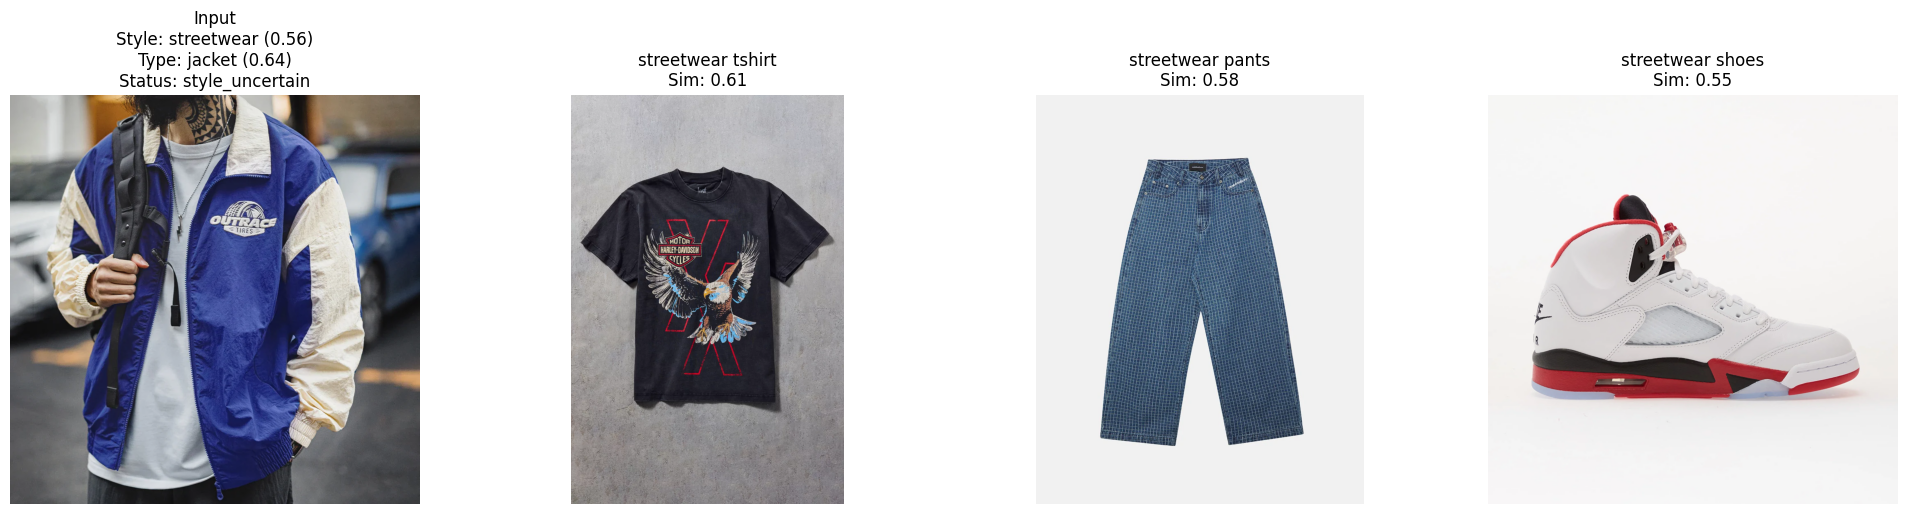

In [20]:
show_recommendations(
    test_image_path,
    prediction,
    recommendations
)

## 14. Create 32-Example Evaluation Set

This experiment uses the same type of balanced real-world evaluation subset as the previous recommendation evaluation framework.

The subset contains:

- 4 styles
- 4 clothing types
- 2 examples per style/type combination
- 32 examples in total

Using the same structure makes it possible to compare this MobileNetV3-based recommendation experiment with the previous ResNet34-based recommendation evaluation.

The real-world test set is only used for evaluation and is not used for training.

In [21]:
def create_balanced_evaluation_set(real_world_dir, examples_per_combination=2):
    evaluation_items = []

    for style in sorted(os.listdir(real_world_dir)):
        style_path = os.path.join(real_world_dir, style)

        if not os.path.isdir(style_path):
            continue

        for item_type in sorted(os.listdir(style_path)):
            type_path = os.path.join(style_path, item_type)

            if not os.path.isdir(type_path):
                continue

            image_files = [
                filename for filename in sorted(os.listdir(type_path))
                if filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            ]

            selected_files = image_files[:examples_per_combination]

            for filename in selected_files:
                image_path = os.path.join(type_path, filename)

                evaluation_items.append({
                    "image_path": image_path,
                    "true_style": style,
                    "true_type": item_type,
                    "filename": filename
                })

    return pd.DataFrame(evaluation_items)


evaluation_df = create_balanced_evaluation_set(
    real_world_dir=real_world_dir,
    examples_per_combination=2
)

print("Number of evaluation examples:", len(evaluation_df))
evaluation_df.head()

Number of evaluation examples: 32


,image_path,true_style,true_type,filename
0,../dataset/real_world_test\formal\jacket\forma...,formal,jacket,formal_jacket_rw_001.png
1,../dataset/real_world_test\formal\jacket\forma...,formal,jacket,formal_jacket_rw_002.png
2,../dataset/real_world_test\formal\pants\formal...,formal,pants,formal_pants_rw_001.png
3,../dataset/real_world_test\formal\pants\formal...,formal,pants,formal_pants_rw_002.png
4,../dataset/real_world_test\formal\shoes\formal...,formal,shoes,formal_shoes_rw_001.png


### 14.1. Check Evaluation Set Distribution

The evaluation set distribution is checked to confirm that the selected examples are balanced across styles and clothing types.

In [22]:
evaluation_distribution = pd.crosstab(
    evaluation_df["true_style"],
    evaluation_df["true_type"]
)

evaluation_distribution

true_type,jacket,pants,shoes,tshirt
true_style,,,,
formal,2,2,2,2
gothic,2,2,2,2
sporty,2,2,2,2
streetwear,2,2,2,2


## 15. Run Automatic Recommendation Evaluation

This section runs the MobileNetV3-based recommendation pipeline on the 32 selected real-world examples.

For each input image, the system records:

- true style
- true clothing type
- predicted style
- predicted clothing type
- style confidence
- type confidence
- safeguard status
- recommended item types
- whether the recommendations include the same actual type as the input

This automatic evaluation checks whether the new style model improves the pipeline before manual scoring is done.

In [23]:
automatic_results = []

for _, row in evaluation_df.iterrows():
    image_path = row["image_path"]
    true_style = row["true_style"]
    true_type = row["true_type"]

    prediction, recommendations = recommend_items_by_embedding(
        image_path,
        catalogue_df,
        catalogue_embeddings
    )

    recommended_types = recommendations["type"].tolist() if len(recommendations) > 0 else []
    recommended_styles = recommendations["style"].tolist() if len(recommendations) > 0 else []
    recommended_files = recommendations["filename"].tolist() if len(recommendations) > 0 else []

    same_actual_type_issue = true_type in recommended_types

    automatic_results.append({
        "input_image": image_path,
        "filename": row["filename"],
        "true_style": true_style,
        "true_type": true_type,
        "predicted_style": prediction["style"],
        "predicted_type": prediction["type"],
        "style_confidence": prediction["style_confidence"],
        "type_confidence": prediction["type_confidence"],
        "safeguard_status": prediction["safeguard_status"],
        "style_correct": prediction["style"] == true_style,
        "type_correct": prediction["type"] == true_type,
        "recommended_styles": recommended_styles,
        "recommended_types": recommended_types,
        "recommended_files": recommended_files,
        "num_recommendations": len(recommendations),
        "same_actual_type_issue": same_actual_type_issue
    })

automatic_results_df = pd.DataFrame(automatic_results)

automatic_results_df.head()

,input_image,filename,true_style,true_type,predicted_style,predicted_type,style_confidence,type_confidence,safeguard_status,style_correct,type_correct,recommended_styles,recommended_types,recommended_files,num_recommendations,same_actual_type_issue
0,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,jacket,formal,jacket,0.743481,0.907646,reliable,True,True,"[formal, formal, formal]","[tshirt, pants, shoes]","[formal_tshirt_050.png, formal_pants_009.png, ...",3,False
1,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,jacket,formal,jacket,0.908396,0.935415,reliable,True,True,"[formal, formal, formal]","[pants, tshirt, shoes]","[formal_pants_012.png, formal_tshirt_050.png, ...",3,False
2,../dataset/real_world_test\formal\pants\formal...,formal_pants_rw_001.png,formal,pants,formal,pants,0.808794,0.737623,reliable,True,True,"[formal, formal, formal]","[tshirt, jacket, shoes]","[formal_tshirt_050.png, formal_jacket_021.png,...",3,False
3,../dataset/real_world_test\formal\pants\formal...,formal_pants_rw_002.png,formal,pants,sporty,pants,0.562956,0.573864,style_and_type_uncertain,False,True,"[sporty, sporty, sporty]","[jacket, tshirt, shoes]","[sporty_jacket_034.png, sporty_tshirt_011.png,...",3,False
4,../dataset/real_world_test\formal\shoes\formal...,formal_shoes_rw_001.png,formal,shoes,formal,shoes,0.555320,0.978442,style_uncertain,True,True,"[formal, formal, formal]","[jacket, pants, tshirt]","[formal_jacket_013.png, formal_pants_002.png, ...",3,False


### 15.1. Automatic Evaluation Summary

The automatic results are summarized to check style accuracy, type accuracy, safeguard behaviour, and structural recommendation issues.

In [24]:
automatic_summary = {
    "num_examples": len(automatic_results_df),
    "style_accuracy": automatic_results_df["style_correct"].mean(),
    "type_accuracy": automatic_results_df["type_correct"].mean(),
    "same_actual_type_issues": automatic_results_df["same_actual_type_issue"].sum(),
    "same_actual_type_issue_rate": automatic_results_df["same_actual_type_issue"].mean(),
    "average_num_recommendations": automatic_results_df["num_recommendations"].mean()
}

automatic_summary_df = pd.DataFrame([automatic_summary])
automatic_summary_df

,num_examples,style_accuracy,type_accuracy,same_actual_type_issues,same_actual_type_issue_rate,average_num_recommendations
0,32,0.65625,0.9375,2,0.0625,3.0


In [25]:
safeguard_distribution = automatic_results_df["safeguard_status"].value_counts().reset_index()
safeguard_distribution.columns = ["safeguard_status", "count"]

safeguard_distribution

,safeguard_status,count
0,reliable,16
1,style_uncertain,10
2,style_and_type_uncertain,5
3,type_uncertain,1


In [26]:
style_prediction_distribution = pd.crosstab(
    automatic_results_df["true_style"],
    automatic_results_df["predicted_style"]
)

style_prediction_distribution

predicted_style,formal,gothic,sporty,streetwear
true_style,,,,
formal,5,0,2,1
gothic,0,5,0,3
sporty,2,0,4,2
streetwear,0,0,1,7


In [27]:
type_prediction_distribution = pd.crosstab(
    automatic_results_df["true_type"],
    automatic_results_df["predicted_type"]
)

type_prediction_distribution

predicted_type,jacket,pants,shoes,tshirt
true_type,,,,
jacket,8,0,0,0
pants,1,7,0,0
shoes,0,0,8,0
tshirt,1,0,0,7


## 16. Save Automatic Evaluation Results

The automatic evaluation results are saved so they can be compared with the previous ResNet34-based recommendation evaluation.

In [28]:
automatic_results_df.to_csv(
    os.path.join(results_dir, "mobilenet_recommendation_automatic_results.csv"),
    index=False
)

automatic_summary_df.to_csv(
    os.path.join(results_dir, "mobilenet_recommendation_automatic_summary.csv"),
    index=False
)

safeguard_distribution.to_csv(
    os.path.join(results_dir, "mobilenet_safeguard_distribution.csv"),
    index=False
)

style_prediction_distribution.to_csv(
    os.path.join(results_dir, "mobilenet_style_prediction_distribution.csv")
)

type_prediction_distribution.to_csv(
    os.path.join(results_dir, "mobilenet_type_prediction_distribution.csv")
)

print("Automatic evaluation results saved successfully.")

Automatic evaluation results saved successfully.


## 17. Automatic Comparison with Previous Evaluation

The MobileNetV3-based recommendation pipeline is compared with the previous ResNet34-based recommendation evaluation.

The goal of this comparison is to check whether replacing the style classifier improved the automatic recommendation metrics before doing manual scoring.

In [29]:
previous_automatic_summary = {
    "setup": "Previous ResNet34 style setup",
    "style_accuracy": 0.5625,
    "type_accuracy": 0.9375,
    "same_actual_type_issues": 2,
    "same_actual_type_issue_rate": 2 / 32
}

new_automatic_summary = {
    "setup": "MobileNetV3 style setup",
    "style_accuracy": automatic_summary_df.loc[0, "style_accuracy"],
    "type_accuracy": automatic_summary_df.loc[0, "type_accuracy"],
    "same_actual_type_issues": automatic_summary_df.loc[0, "same_actual_type_issues"],
    "same_actual_type_issue_rate": automatic_summary_df.loc[0, "same_actual_type_issue_rate"]
}

automatic_comparison_df = pd.DataFrame([
    previous_automatic_summary,
    new_automatic_summary
])

automatic_comparison_df

,setup,style_accuracy,type_accuracy,same_actual_type_issues,same_actual_type_issue_rate
0,Previous ResNet34 style setup,0.56250,0.9375,2,0.0625
1,MobileNetV3 style setup,0.65625,0.9375,2,0.0625


In [30]:
automatic_comparison_df.to_csv(
    os.path.join(results_dir, "automatic_comparison_with_previous_setup.csv"),
    index=False
)

print("Automatic comparison saved successfully.")

Automatic comparison saved successfully.


### 17.1. Automatic Comparison Interpretation

The automatic evaluation shows that the MobileNetV3 style classifier improved style prediction on the 32-example recommendation subset.

The previous ResNet34-based setup achieved a style accuracy of **0.5625**, while the MobileNetV3-based setup achieved **0.65625**. This is an improvement of **0.09375**, or 9.375 percentage points.

The type accuracy stayed the same at **0.9375**, which is expected because the type classifier was not changed.

The number of same-actual-type recommendation issues also stayed the same at **2 out of 32**. This suggests that replacing the style classifier did not improve structural recommendation issues. This makes sense because those issues are mainly affected by clothing type prediction, not style prediction.

The safeguard distribution showed that only 16 out of 32 examples were marked as reliable. The remaining examples were marked as style uncertain, type uncertain, or style and type uncertain. This suggests that the MobileNetV3 style model may be more cautious in its confidence scores, so the usefulness of these warnings should be checked during manual evaluation.

Overall, the automatic evaluation is promising because MobileNetV3 improved style accuracy without reducing type accuracy. However, manual scoring is still needed to check whether this improvement actually leads to better style consistency, visual coherence, and overall recommendation quality.

## 18. Manual Recommendation Evaluation

The automatic evaluation showed that the MobileNetV3 style classifier improved the style prediction accuracy inside the recommendation pipeline.

The previous ResNet34 recommendation setup had:

```text
Style accuracy: 0.5625
Type accuracy: 0.9375
Same-actual-type issues: 2 / 32
```

The new MobileNetV3 recommendation setup achieved:

```text
Style accuracy: 0.65625
Type accuracy: 0.9375
Same-actual-type issues: 2 / 32
```

This means the MobileNetV3 style classifier improved style accuracy by:

`0.65625 - 0.5625 = 0.09375`

So the new setup gives a **9.375** percentage point improvement in style prediction on the 32-example recommendation subset.

However, automatic results are not enough to prove that the recommendations are visually better. A recommendation can be technically correct, but still look weak as an outfit. For example, it may avoid the same clothing type, but still fail in style consistency, colour matching, or overall outfit coherence.

Because of this, I will now manually evaluate the recommendation quality.

The manual evaluation will use the same criteria as the previous recommendation evaluation:

| Criterion                     | Score range |
| ----------------------------- | ----------- |
| structural validity           | 0, 1, or 2  |
| style consistency             | 0, 1, or 2  |
| visual coherence              | 0, 1, or 2  |
| confidence warning usefulness | 0, 1, or 2  |
| overall quality               | 0, 1, or 2  |

The meaning of the scores is:

```text
0 = bad / not useful
1 = partially useful
2 = good / useful
```

Each of the 32 recommendation examples will be scored manually. I will also add notes for each example to explain why the recommendation was good, partially useful, or bad.

### 18.1 Manual Scoring Workflow

For the manual evaluation, I will use a CSV-based scoring workflow.

The reason for this is that manual scoring is easier and more reliable when the automatic results, predictions, recommendation outputs, and score columns are stored in one table.

The workflow will be:

1. Start from the automatic recommendation results.
2. Add empty manual score columns.
3. Save the table as a CSV file.
4. Open the CSV and manually fill in the scores while looking at the recommendation results.
5. Add short notes for each example.
6. Load the completed CSV back into the notebook.
7. Calculate the average manual scores.
8. Compare the new MobileNetV3 manual scores with the previous ResNet34 manual scores.

This workflow is useful because it keeps the evaluation structured. It also makes the results easier to save, review, and compare later.

The manual evaluation table will contain one row for each of the 32 real-world examples. Each row will include the automatic prediction information and the manual score columns.

The manual score columns will be:

| Column | Purpose |
| ------ | ------- |
| structural_validity | Score for whether the recommendation avoids the same clothing type and gives useful outfit categories |
| style_consistency | Score for whether the recommendations match the intended style |
| visual_coherence | Score for whether the recommended items visually work with the input item |
| confidence_warning_usefulness | Score for whether the confidence warning is helpful |
| overall_quality | Final overall usefulness score |
| manual_notes | Short explanation of the manual judgement |

The scores will use the same scale as before:

```text
0 = bad / not useful
1 = partially useful
2 = good / useful
```

### 18.2 Create Manual Evaluation Template

Next, I will create a manual evaluation CSV template.

This template starts from the automatic recommendation results, because those results already contain the input examples, predictions, confidence values, safeguard status, and recommendation outputs.

Then I add empty columns for the manual scores.

The goal is to create a file that I can fill in manually after inspecting the 32 recommendation examples.

The manual evaluation CSV will be saved inside the experiment results folder so it stays connected to this MobileNetV3 recommendation experiment.

In [32]:
from pathlib import Path

# Convert results_dir to a Path object if it is currently a string
results_dir = Path(results_dir)

# Create a folder for manual evaluation files
manual_eval_dir = results_dir / "manual_evaluation"
manual_eval_dir.mkdir(parents=True, exist_ok=True)

manual_eval_csv_path = manual_eval_dir / "mobilenet_manual_evaluation_template.csv"

manual_eval_csv_path

WindowsPath('../results/recommendation_mobilenet_style_model/manual_evaluation/mobilenet_manual_evaluation_template.csv')

In [33]:
# Create manual evaluation template from automatic results

manual_eval_df = automatic_results_df.copy()

manual_score_columns = [
    "structural_validity",
    "style_consistency",
    "visual_coherence",
    "confidence_warning_usefulness",
    "overall_quality",
    "manual_notes"
]

for col in manual_score_columns:
    if col not in manual_eval_df.columns:
        manual_eval_df[col] = ""

manual_eval_df.to_csv(manual_eval_csv_path, index=False)

print(f"Manual evaluation template saved to: {manual_eval_csv_path}")
manual_eval_df.head()

Manual evaluation template saved to: ..\results\recommendation_mobilenet_style_model\manual_evaluation\mobilenet_manual_evaluation_template.csv


,input_image,filename,true_style,true_type,predicted_style,predicted_type,style_confidence,type_confidence,safeguard_status,style_correct,...,recommended_types,recommended_files,num_recommendations,same_actual_type_issue,structural_validity,style_consistency,visual_coherence,confidence_warning_usefulness,overall_quality,manual_notes
0,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,jacket,formal,jacket,0.743481,0.907646,reliable,True,...,"[tshirt, pants, shoes]","[formal_tshirt_050.png, formal_pants_009.png, ...",3,False,,,,,,
1,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,jacket,formal,jacket,0.908396,0.935415,reliable,True,...,"[pants, tshirt, shoes]","[formal_pants_012.png, formal_tshirt_050.png, ...",3,False,,,,,,
2,../dataset/real_world_test\formal\pants\formal...,formal_pants_rw_001.png,formal,pants,formal,pants,0.808794,0.737623,reliable,True,...,"[tshirt, jacket, shoes]","[formal_tshirt_050.png, formal_jacket_021.png,...",3,False,,,,,,
3,../dataset/real_world_test\formal\pants\formal...,formal_pants_rw_002.png,formal,pants,sporty,pants,0.562956,0.573864,style_and_type_uncertain,False,...,"[jacket, tshirt, shoes]","[sporty_jacket_034.png, sporty_tshirt_011.png,...",3,False,,,,,,
4,../dataset/real_world_test\formal\shoes\formal...,formal_shoes_rw_001.png,formal,shoes,formal,shoes,0.555320,0.978442,style_uncertain,True,...,"[jacket, pants, tshirt]","[formal_jacket_013.png, formal_pants_002.png, ...",3,False,,,,,,


### 18.3 Generate Visual Evaluation Sheets

To make manual scoring faster, I will generate visual evaluation sheets.

Each sheet shows four recommendation examples. This is faster than opening every example separately.

Each example shows:

- the Excel row number
- the input image
- the true style and type
- the predicted style and type
- the style and type confidence values
- the confidence safeguard status
- the three recommended items

The visual sheets will be used for manual scoring. For each example, I will assign scores for:

- structural validity
- style consistency
- visual coherence
- confidence warning usefulness
- overall quality

Since there are 32 evaluation examples and each sheet shows 4 examples, this creates 8 visual sheets in total.

In [39]:
import ast
import math
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

In [40]:
# Create folder for visual scoring sheets

visual_sheets_dir = manual_eval_dir / "visual_scoring_sheets"
visual_sheets_dir.mkdir(parents=True, exist_ok=True)

visual_sheets_dir

WindowsPath('../results/recommendation_mobilenet_style_model/manual_evaluation/visual_scoring_sheets')

In [41]:
def parse_saved_list(value):
    """
    Converts list-like strings or comma-separated strings into Python lists.
    This is needed because recommendation styles, types, and files may be saved as strings in the CSV.
    """

    if isinstance(value, list):
        return value

    if isinstance(value, str):
        value = value.strip()

        # Example format: "['formal', 'formal', 'formal']"
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        # Example format: "pants, shoes, tshirt"
        if "," in value:
            return [
                item.strip().strip("'").strip('"')
                for item in value.split(",")
            ]

        if value:
            return [value.strip("'").strip('"')]

    return []

In [42]:
def build_recommendation_paths(row):
    """
    Builds full image paths for the recommended catalogue items.

    The dataframe contains:
    - recommended_styles
    - recommended_types
    - recommended_files

    The actual images are stored inside:
    catalogue_root / style / type / filename
    """

    styles = parse_saved_list(row.get("recommended_styles", ""))
    types = parse_saved_list(row.get("recommended_types", ""))
    files = parse_saved_list(row.get("recommended_files", ""))

    recommendation_paths = []

    for style, item_type, filename in zip(styles, types, files):
        path = Path(catalogue_root) / style / item_type / filename
        recommendation_paths.append(str(path))

    return recommendation_paths


manual_eval_df["recommendation_paths"] = manual_eval_df.apply(
    build_recommendation_paths,
    axis=1
)

manual_eval_df[
    [
        "filename",
        "recommended_styles",
        "recommended_types",
        "recommended_files",
        "recommendation_paths"
    ]
].head()

,filename,recommended_styles,recommended_types,recommended_files,recommendation_paths
0,formal_jacket_rw_001.png,"[formal, formal, formal]","[tshirt, pants, shoes]","[formal_tshirt_050.png, formal_pants_009.png, ...",[..\dataset\cleaned\formal\tshirt\formal_tshir...
1,formal_jacket_rw_002.png,"[formal, formal, formal]","[pants, tshirt, shoes]","[formal_pants_012.png, formal_tshirt_050.png, ...",[..\dataset\cleaned\formal\pants\formal_pants_...
2,formal_pants_rw_001.png,"[formal, formal, formal]","[tshirt, jacket, shoes]","[formal_tshirt_050.png, formal_jacket_021.png,...",[..\dataset\cleaned\formal\tshirt\formal_tshir...
3,formal_pants_rw_002.png,"[sporty, sporty, sporty]","[jacket, tshirt, shoes]","[sporty_jacket_034.png, sporty_tshirt_011.png,...",[..\dataset\cleaned\sporty\jacket\sporty_jacke...
4,formal_shoes_rw_001.png,"[formal, formal, formal]","[jacket, pants, tshirt]","[formal_jacket_013.png, formal_pants_002.png, ...",[..\dataset\cleaned\formal\jacket\formal_jacke...


In [43]:
def create_visual_scoring_sheet(df, start_idx, end_idx, save_path):
    """
    Creates one visual scoring sheet.

    Each row shows:
    - input image
    - recommendation 1
    - recommendation 2
    - recommendation 3
    """

    selected_df = df.iloc[start_idx:end_idx].reset_index(drop=False)

    examples_count = len(selected_df)
    max_images_per_example = 4  # input + 3 recommendations

    fig, axes = plt.subplots(
        examples_count,
        max_images_per_example,
        figsize=(max_images_per_example * 4.5, examples_count * 4.5)
    )

    if examples_count == 1:
        axes = [axes]

    for row_pos, (_, row) in enumerate(selected_df.iterrows()):
        original_index = row["index"]
        excel_row = original_index + 2

        input_path = row["input_image"]
        recommendation_paths = row["recommendation_paths"]

        if isinstance(recommendation_paths, str):
            recommendation_paths = parse_saved_list(recommendation_paths)

        all_paths = [input_path] + recommendation_paths[:3]

        for col_pos in range(max_images_per_example):
            ax = axes[row_pos][col_pos]

            if col_pos < len(all_paths):
                image_path = all_paths[col_pos]

                try:
                    img = Image.open(image_path).convert("RGB")
                    ax.imshow(img)
                except Exception:
                    ax.text(
                        0.5,
                        0.5,
                        f"Image not found:\n{image_path}",
                        ha="center",
                        va="center",
                        wrap=True
                    )

                if col_pos == 0:
                    title = (
                        f"Excel row: {excel_row}\n"
                        f"Input: {row.get('filename', '')}\n"
                        f"True: {row.get('true_style', '')} / {row.get('true_type', '')}\n"
                        f"Pred: {row.get('predicted_style', '')} / {row.get('predicted_type', '')}\n"
                        f"Style conf: {row.get('style_confidence', 0):.2f}\n"
                        f"Type conf: {row.get('type_confidence', 0):.2f}\n"
                        f"Status: {row.get('safeguard_status', '')}"
                    )
                else:
                    rec_index = col_pos - 1

                    rec_styles = parse_saved_list(row.get("recommended_styles", ""))
                    rec_types = parse_saved_list(row.get("recommended_types", ""))

                    rec_style = rec_styles[rec_index] if rec_index < len(rec_styles) else ""
                    rec_type = rec_types[rec_index] if rec_index < len(rec_types) else ""

                    title = (
                        f"Recommendation {col_pos}\n"
                        f"{rec_style} / {rec_type}"
                    )

                ax.set_title(title, fontsize=9)
            else:
                ax.axis("off")

            ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

In [44]:
# Generate 8 visual sheets, with 4 examples per sheet

examples_per_sheet = 4
num_examples = len(manual_eval_df)
num_sheets = math.ceil(num_examples / examples_per_sheet)

saved_sheet_paths = []

for sheet_idx in range(num_sheets):
    start_idx = sheet_idx * examples_per_sheet
    end_idx = min(start_idx + examples_per_sheet, num_examples)

    save_path = visual_sheets_dir / (
        f"manual_scoring_sheet_{sheet_idx + 1:02d}_"
        f"rows_{start_idx + 2}_to_{end_idx + 1}.png"
    )

    create_visual_scoring_sheet(
        manual_eval_df,
        start_idx,
        end_idx,
        save_path
    )

    saved_sheet_paths.append(save_path)

print("Saved visual scoring sheets:")

for path in saved_sheet_paths:
    print(path)

Saved visual scoring sheets:
..\results\recommendation_mobilenet_style_model\manual_evaluation\visual_scoring_sheets\manual_scoring_sheet_01_rows_2_to_5.png
..\results\recommendation_mobilenet_style_model\manual_evaluation\visual_scoring_sheets\manual_scoring_sheet_02_rows_6_to_9.png
..\results\recommendation_mobilenet_style_model\manual_evaluation\visual_scoring_sheets\manual_scoring_sheet_03_rows_10_to_13.png
..\results\recommendation_mobilenet_style_model\manual_evaluation\visual_scoring_sheets\manual_scoring_sheet_04_rows_14_to_17.png
..\results\recommendation_mobilenet_style_model\manual_evaluation\visual_scoring_sheets\manual_scoring_sheet_05_rows_18_to_21.png
..\results\recommendation_mobilenet_style_model\manual_evaluation\visual_scoring_sheets\manual_scoring_sheet_06_rows_22_to_25.png
..\results\recommendation_mobilenet_style_model\manual_evaluation\visual_scoring_sheets\manual_scoring_sheet_07_rows_26_to_29.png
..\results\recommendation_mobilenet_style_model\manual_evaluation

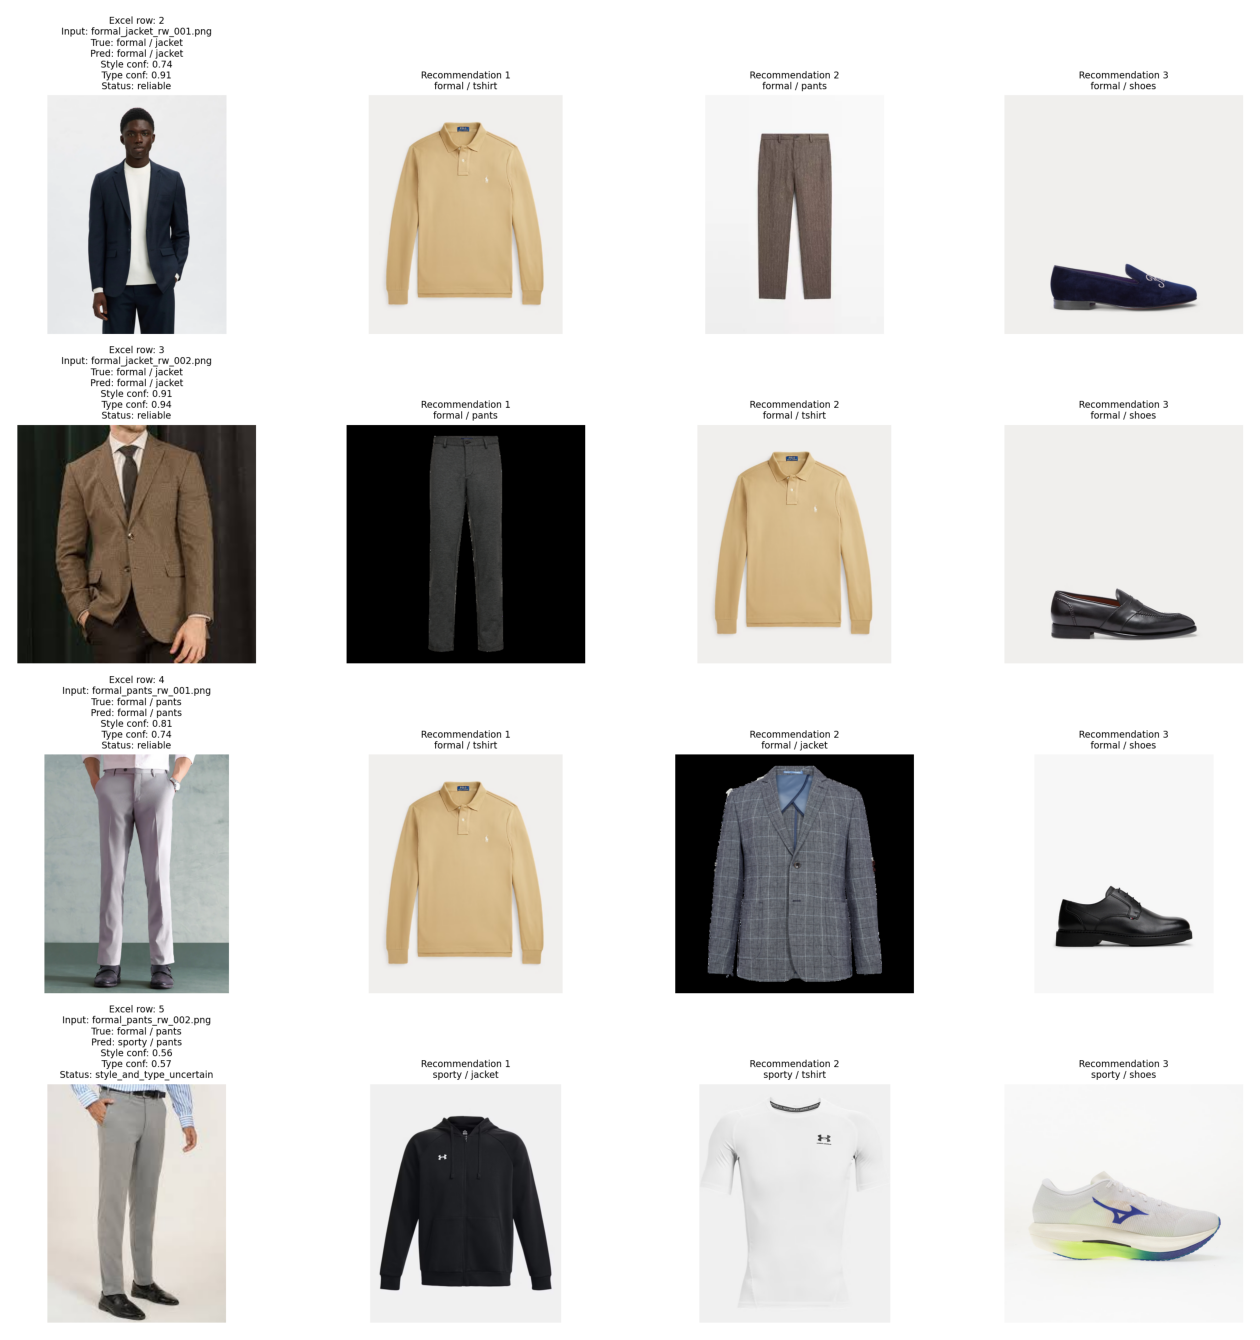

In [45]:
# Optional: display the first visual scoring sheet inside the notebook

first_sheet_path = saved_sheet_paths[0]

img = Image.open(first_sheet_path)
plt.figure(figsize=(16, 18))
plt.imshow(img)
plt.axis("off")
plt.show()

## 19. Load Completed Manual Evaluation

Now that the manual scoring file has been completed, I will load it back into the notebook.

To avoid CSV formatting problems, the completed manual scores are stored in a clean Excel file with only the required scoring columns.

The file contains:

- filename
- structural validity score
- style consistency score
- visual coherence score
- confidence warning usefulness score
- overall quality score
- manual notes

After loading the scores, I merge them back with the automatic evaluation results. This gives one complete evaluation table with both automatic metrics and manual scores.

In [57]:
# Load clean completed manual scores

manual_scores_path = manual_eval_dir / "mobilenet_manual_scores_only_clean.xlsx"

manual_scores_df = pd.read_excel(manual_scores_path)

print("Rows:", len(manual_scores_df))
print("Columns:", manual_scores_df.columns.tolist())

manual_scores_df.head()

Rows: 32
Columns: ['filename', 'structural_validity', 'style_consistency', 'visual_coherence', 'confidence_warning_usefulness', 'overall_quality', 'manual_notes']


,filename,structural_validity,style_consistency,visual_coherence,confidence_warning_usefulness,overall_quality,manual_notes
0,formal_jacket_rw_001.png,2,2,1,2,2,Structurally valid because it recommends tshir...
1,formal_jacket_rw_002.png,2,2,2,2,2,Strong recommendation. The input is formal and...
2,formal_pants_rw_001.png,2,2,2,2,2,Good formal recommendation. The input pants ar...
3,formal_pants_rw_002.png,2,0,0,2,0,Structurally valid because it recommends jacke...
4,formal_shoes_rw_001.png,2,2,2,1,2,Structurally valid because it recommends jacke...


In [58]:
# Keep only the required score columns

required_score_columns = [
    "filename",
    "structural_validity",
    "style_consistency",
    "visual_coherence",
    "confidence_warning_usefulness",
    "overall_quality",
    "manual_notes"
]

manual_scores_df = manual_scores_df[required_score_columns].copy()

manual_scores_df.head()

,filename,structural_validity,style_consistency,visual_coherence,confidence_warning_usefulness,overall_quality,manual_notes
0,formal_jacket_rw_001.png,2,2,1,2,2,Structurally valid because it recommends tshir...
1,formal_jacket_rw_002.png,2,2,2,2,2,Strong recommendation. The input is formal and...
2,formal_pants_rw_001.png,2,2,2,2,2,Good formal recommendation. The input pants ar...
3,formal_pants_rw_002.png,2,0,0,2,0,Structurally valid because it recommends jacke...
4,formal_shoes_rw_001.png,2,2,2,1,2,Structurally valid because it recommends jacke...


In [59]:
# Merge manual scores back into the full automatic evaluation table

manual_completed_df = manual_eval_df.drop(
    columns=[
        "structural_validity",
        "style_consistency",
        "visual_coherence",
        "confidence_warning_usefulness",
        "overall_quality",
        "manual_notes"
    ],
    errors="ignore"
).merge(
    manual_scores_df,
    on="filename",
    how="left"
)

print("Rows:", len(manual_completed_df))
manual_completed_df.head()

Rows: 32


,input_image,filename,true_style,true_type,predicted_style,predicted_type,style_confidence,type_confidence,safeguard_status,style_correct,...,recommended_files,num_recommendations,same_actual_type_issue,recommendation_paths,structural_validity,style_consistency,visual_coherence,confidence_warning_usefulness,overall_quality,manual_notes
0,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,jacket,formal,jacket,0.743481,0.907646,reliable,True,...,"[formal_tshirt_050.png, formal_pants_009.png, ...",3,False,[..\dataset\cleaned\formal\tshirt\formal_tshir...,2,2,1,2,2,Structurally valid because it recommends tshir...
1,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,jacket,formal,jacket,0.908396,0.935415,reliable,True,...,"[formal_pants_012.png, formal_tshirt_050.png, ...",3,False,[..\dataset\cleaned\formal\pants\formal_pants_...,2,2,2,2,2,Strong recommendation. The input is formal and...
2,../dataset/real_world_test\formal\pants\formal...,formal_pants_rw_001.png,formal,pants,formal,pants,0.808794,0.737623,reliable,True,...,"[formal_tshirt_050.png, formal_jacket_021.png,...",3,False,[..\dataset\cleaned\formal\tshirt\formal_tshir...,2,2,2,2,2,Good formal recommendation. The input pants ar...
3,../dataset/real_world_test\formal\pants\formal...,formal_pants_rw_002.png,formal,pants,sporty,pants,0.562956,0.573864,style_and_type_uncertain,False,...,"[sporty_jacket_034.png, sporty_tshirt_011.png,...",3,False,[..\dataset\cleaned\sporty\jacket\sporty_jacke...,2,0,0,2,0,Structurally valid because it recommends jacke...
4,../dataset/real_world_test\formal\shoes\formal...,formal_shoes_rw_001.png,formal,shoes,formal,shoes,0.555320,0.978442,style_uncertain,True,...,"[formal_jacket_013.png, formal_pants_002.png, ...",3,False,[..\dataset\cleaned\formal\jacket\formal_jacke...,2,2,2,1,2,Structurally valid because it recommends jacke...


In [60]:
# Validate that all manual score columns are filled

manual_score_columns = [
    "structural_validity",
    "style_consistency",
    "visual_coherence",
    "confidence_warning_usefulness",
    "overall_quality"
]

manual_completed_df[manual_score_columns].isna().sum()

structural_validity              0
style_consistency                0
visual_coherence                 0
confidence_warning_usefulness    0
overall_quality                  0
dtype: int64

In [61]:
# Validate that scores only contain 0, 1, or 2

for column in manual_score_columns:
    values = sorted(manual_completed_df[column].dropna().unique())
    print(column, values)

structural_validity [np.int64(0), np.int64(2)]
style_consistency [np.int64(0), np.int64(1), np.int64(2)]
visual_coherence [np.int64(0), np.int64(1), np.int64(2)]
confidence_warning_usefulness [np.int64(0), np.int64(1), np.int64(2)]
overall_quality [np.int64(0), np.int64(1), np.int64(2)]


## 20. Manual Evaluation Summary

After loading and validating the completed manual evaluation, I summarize the manual scores.

The summary calculates the average, median, minimum, and maximum score for each manual criterion.

Since each criterion is scored from 0 to 2:

- scores closer to 2 mean stronger recommendation quality
- scores around 1 mean partially useful recommendation quality
- scores closer to 0 mean weak recommendation quality

This summary gives a clear overview of how well the MobileNetV3-based recommendation setup performed from a visual and practical recommendation perspective.

In [62]:
manual_score_summary = manual_completed_df[manual_score_columns].agg(
    ["mean", "median", "min", "max"]
).transpose().reset_index()

manual_score_summary = manual_score_summary.rename(columns={
    "index": "criterion",
    "mean": "average_score",
    "median": "median_score",
    "min": "minimum_score",
    "max": "maximum_score"
})

manual_score_summary

,criterion,average_score,median_score,minimum_score,maximum_score
0,structural_validity,1.93750,2.0,0.0,2.0
1,style_consistency,1.46875,2.0,0.0,2.0
2,visual_coherence,1.37500,2.0,0.0,2.0
3,confidence_warning_usefulness,1.56250,2.0,0.0,2.0
4,overall_quality,1.40625,2.0,0.0,2.0


In [63]:
score_distribution_rows = []

for column in manual_score_columns:
    value_counts = manual_completed_df[column].value_counts().sort_index()

    score_distribution_rows.append({
        "criterion": column,
        "score_0_count": int(value_counts.get(0, 0)),
        "score_1_count": int(value_counts.get(1, 0)),
        "score_2_count": int(value_counts.get(2, 0))
    })

score_distribution_df = pd.DataFrame(score_distribution_rows)

score_distribution_df

,criterion,score_0_count,score_1_count,score_2_count
0,structural_validity,1,0,31
1,style_consistency,6,5,21
2,visual_coherence,6,8,18
3,confidence_warning_usefulness,4,6,22
4,overall_quality,6,7,19


In [64]:
overall_quality_counts = manual_completed_df["overall_quality"].value_counts().sort_index()

overall_quality_summary = pd.DataFrame({
    "overall_quality_score": [0, 1, 2],
    "meaning": ["bad", "partially useful", "good"],
    "count": [
        int(overall_quality_counts.get(0, 0)),
        int(overall_quality_counts.get(1, 0)),
        int(overall_quality_counts.get(2, 0))
    ]
})

overall_quality_summary["percentage"] = (
    overall_quality_summary["count"] / len(manual_completed_df)
)

overall_quality_summary

,overall_quality_score,meaning,count,percentage
0,0,bad,6,0.18750
1,1,partially useful,7,0.21875
2,2,good,19,0.59375


### 20.1 Manual Evaluation Interpretation

The manual evaluation shows that the MobileNetV3-based recommendation setup performs strongest in structural validity.

The average structural validity score is **1.9375** out of 2. This means that the recommender almost always returns useful complementary clothing types and avoids recommending the same actual clothing type as the input item. Only 1 out of 32 examples received a structural validity score of 0.

The style consistency score is **1.46875** out of 2. This is higher than the previous ResNet34-based setup and suggests that the MobileNetV3 style classifier improves the visual style match of the recommendations. However, the score is still not perfect, because some examples are still predicted as the wrong style and therefore retrieve items from the wrong catalogue category.

The visual coherence score is **1.3750** out of 2. This shows that the recommendations are often visually usable, but not always fully coherent as an outfit. Some recommendations match the correct style but still have weaker colour, shape, or outfit compatibility.

The confidence warning usefulness score is **1.5625** out of 2. This means the safeguard system is generally useful, but not perfect. In several cases, the system correctly warned when the prediction was uncertain. However, there were also examples where the model was confidently wrong, so the output was marked as reliable even though the recommendation quality was weaker.

The average overall quality score is **1.40625** out of 2. This means the MobileNetV3 recommendation setup is slightly better than the previous setup, but it is still not fully reliable.

The overall quality distribution shows:

```text
Good recommendations: 19
Partially useful recommendations: 7
Bad recommendations: 6
```

This means that 59.375% of the evaluated recommendations were scored as good. Compared with the previous setup, this is an improvement because the number of good recommendations increased and the number of bad recommendations decreased.

Overall, the manual evaluation confirms that MobileNetV3 improves the recommendation pipeline, especially in style consistency and overall quality. However, the system still has limitations when the style prediction is wrong or when visually similar styles overlap, such as gothic, sporty, and streetwear.

## 21. Comparison with Previous Manual Evaluation

The previous recommendation evaluation used the ResNet34 style classifier.

The previous manual evaluation results were:

| Criterion | Previous ResNet34 score |
|---|---:|
| Structural validity | 1.8750 |
| Style consistency | 1.3125 |
| Visual coherence | 1.3125 |
| Confidence warning usefulness | 1.4688 |
| Overall quality | 1.3125 |

The previous overall quality distribution was:

| Quality label | Count |
|---|---:|
| Good | 17 |
| Partially useful | 8 |
| Bad | 7 |

The new MobileNetV3 manual scores are compared against these baseline values to check whether the new style classifier improved actual recommendation quality.

In [65]:
previous_manual_scores = {
    "structural_validity": 1.8750,
    "style_consistency": 1.3125,
    "visual_coherence": 1.3125,
    "confidence_warning_usefulness": 1.4688,
    "overall_quality": 1.3125
}

previous_manual_df = pd.DataFrame.from_dict(
    previous_manual_scores,
    orient="index",
    columns=["previous_resnet34"]
)

new_manual_df = manual_score_summary.set_index("criterion")[["average_score"]]
new_manual_df = new_manual_df.rename(columns={
    "average_score": "new_mobilenetv3"
})

manual_comparison_df = previous_manual_df.join(new_manual_df)

manual_comparison_df["difference"] = (
    manual_comparison_df["new_mobilenetv3"] -
    manual_comparison_df["previous_resnet34"]
)

manual_comparison_df

,previous_resnet34,new_mobilenetv3,difference
structural_validity,1.8750,1.93750,0.06250
style_consistency,1.3125,1.46875,0.15625
visual_coherence,1.3125,1.37500,0.06250
confidence_warning_usefulness,1.4688,1.56250,0.09370
overall_quality,1.3125,1.40625,0.09375


### 21.1 Manual Comparison Interpretation

The manual comparison shows that the MobileNetV3-based recommendation setup improved all manual evaluation criteria compared with the previous ResNet34-based setup.

The biggest improvement is in **style consistency**, which increased from **1.3125** to **1.46875**. This is an improvement of **0.15625**. This is important because style consistency was one of the main weaknesses in the previous recommendation evaluation. The result suggests that MobileNetV3 helps the recommender retrieve items from a more suitable style category more often.

The **overall quality** score increased from **1.3125** to **1.40625**, which is an improvement of **0.09375**. This means that the recommendations became slightly more useful overall. The improvement is not huge, but it is consistent with the automatic style accuracy improvement seen earlier in the notebook.

The **confidence warning usefulness** score also improved from **1.4688** to **1.5625**. This suggests that the safeguard system worked slightly better with the MobileNetV3 setup. In many uncertain cases, the warning helped explain why a recommendation should be treated carefully.

The **structural validity** score improved slightly from **1.8750** to **1.9375**. This was not the main expected improvement, because the clothing type classifier was not changed. However, the result still shows that the new setup remained structurally reliable.

The **visual coherence** score increased from **1.3125** to **1.3750**. This means that the recommendations became slightly more visually compatible, but this area still remains weaker than structural validity.

Overall, the manual comparison supports the automatic evaluation result. MobileNetV3 improved style prediction accuracy, and this also led to a small but clear improvement in manual recommendation quality. However, the improvement is moderate, not dramatic. The recommender still struggles when visually similar styles overlap, especially between gothic, sporty, and streetwear.

In [66]:
previous_quality_distribution = {
    "bad": 7,
    "partially_useful": 8,
    "good": 17
}

new_quality_distribution = {
    "bad": int(overall_quality_summary.loc[
        overall_quality_summary["meaning"] == "bad",
        "count"
    ].values[0]),
    "partially_useful": int(overall_quality_summary.loc[
        overall_quality_summary["meaning"] == "partially useful",
        "count"
    ].values[0]),
    "good": int(overall_quality_summary.loc[
        overall_quality_summary["meaning"] == "good",
        "count"
    ].values[0])
}

quality_distribution_comparison_df = pd.DataFrame([
    {
        "quality_label": "bad",
        "previous_resnet34": previous_quality_distribution["bad"],
        "new_mobilenetv3": new_quality_distribution["bad"],
        "difference": new_quality_distribution["bad"] - previous_quality_distribution["bad"]
    },
    {
        "quality_label": "partially_useful",
        "previous_resnet34": previous_quality_distribution["partially_useful"],
        "new_mobilenetv3": new_quality_distribution["partially_useful"],
        "difference": new_quality_distribution["partially_useful"] - previous_quality_distribution["partially_useful"]
    },
    {
        "quality_label": "good",
        "previous_resnet34": previous_quality_distribution["good"],
        "new_mobilenetv3": new_quality_distribution["good"],
        "difference": new_quality_distribution["good"] - previous_quality_distribution["good"]
    }
])

quality_distribution_comparison_df

,quality_label,previous_resnet34,new_mobilenetv3,difference
0,bad,7,6,-1
1,partially_useful,8,7,-1
2,good,17,19,2


### 21.2 Overall Quality Distribution Comparison

The overall quality distribution also improved with the MobileNetV3-based setup.

The previous ResNet34 setup had:

```text
Good: 17
Partially useful: 8
Bad: 7
```

The new MobileNetV3 setup has:

```text
Good: 19
Partially useful: 7
Bad: 6
```

This means that the number of good recommendations increased by 2. The number of partially useful recommendations decreased by 1, and the number of bad recommendations also decreased by 1.

This supports the average score comparison. MobileNetV3 does not completely solve the recommendation quality problem, but it does move the results in the right direction. More recommendations are now judged as good, and fewer are judged as bad.

## 22. Results Interpretation

The results show that replacing the ResNet34 style classifier with MobileNetV3 Large improved the recommendation pipeline.

The automatic evaluation showed a clear improvement in style prediction accuracy. The previous ResNet34 setup achieved **0.5625** style accuracy on the 32-example recommendation subset, while the MobileNetV3 setup achieved **0.65625**. This is a **9.375 percentage point improvement**.

The type accuracy stayed the same at **0.9375**, which is expected because the type classifier was not changed. The number of same-actual-type recommendation issues also stayed the same at **2 out of 32**. This confirms that the main effect of the new experiment comes from the style classifier, not from changes in the type classifier or recommendation logic.

The manual evaluation also improved. All five manual criteria increased compared with the previous ResNet34 setup:

- structural validity improved by **0.0625**
- style consistency improved by **0.15625**
- visual coherence improved by **0.0625**
- confidence warning usefulness improved by **0.0937**
- overall quality improved by **0.09375**

The most important improvement is style consistency. This makes sense because MobileNetV3 was introduced specifically to improve style classification. Better style prediction means that the recommender is more likely to filter the catalogue using the correct style category, which improves the visual relevance of the recommended items.

The overall quality distribution also improved. Good recommendations increased from **17** to **19**, while bad recommendations decreased from **7** to **6**. This shows that the improvement is visible in the actual recommendation output, not only in the automatic classification metric.

However, the improvement is moderate. The system still makes style errors, especially when styles visually overlap. Some gothic, sporty, and streetwear examples are still difficult because they can share similar colours, silhouettes, or casual clothing elements.

Overall, the MobileNetV3 style classifier is better than the previous ResNet34 style classifier for this recommendation pipeline. It improves style accuracy and gives slightly better manual recommendation quality, while keeping the rest of the system stable.

## 23. Limitations

This experiment shows that MobileNetV3 improves the recommendation pipeline, but there are still several limitations.

First, the manual evaluation is subjective. Outfit quality does not have one single correct answer. The same recommendation could be judged differently by another evaluator depending on personal taste, fashion knowledge, or interpretation of the style categories. To reduce this issue, I used the same 0 to 2 scoring system as the previous evaluation, but the scores are still partly based on human judgement.

Second, the evaluation uses only 32 real-world examples. This is useful because the subset is balanced across 4 styles and 4 clothing types, but it is still a small test set. A larger evaluation set would give a more reliable view of how well the system performs in general.

Third, only one recommendation catalogue was used. The recommendation quality depends heavily on the available catalogue items. If the catalogue contains weak, repetitive, or visually limited items for a certain style, the recommender may still produce weaker results even when the classifier predicts the correct style.

Fourth, the recommendation ranking still uses ResNet34 image embeddings and cosine similarity. These embeddings are useful for visual similarity, but they are not specifically trained for fashion compatibility. This means the system may retrieve visually similar items that are not necessarily the best outfit match.

Fifth, the system still depends strongly on predicted labels. If the style classifier predicts the wrong style, the recommender filters the catalogue using the wrong style category. This usually leads to recommendations that are structurally valid but stylistically wrong.

Sixth, the confidence safeguard is helpful but not perfect. Some incorrect predictions are still made with high confidence, so they are marked as reliable even when the recommendation quality is weak. This shows that confidence alone is not always enough to detect risky recommendations.

Finally, the project only uses four style classes and four clothing type classes. This makes the prototype easier to evaluate, but it also limits real-world usefulness. A complete outfit recommendation system would need more styles, more clothing types, and probably more detailed fashion attributes such as colour, material, occasion, and season.

## 24. Conclusion

This experiment tested whether replacing the ResNet34 style classifier with a MobileNetV3 Large style classifier improves the full outfit recommendation pipeline.

The automatic evaluation showed that MobileNetV3 improved style prediction accuracy on the 32-example recommendation subset. Style accuracy increased from **0.5625** to **0.65625**, which is a **9.375 percentage point improvement**.

The type accuracy stayed the same at **0.9375**, and the number of same-actual-type recommendation issues stayed the same at **2 out of 32**. This makes sense because the type classifier and recommendation logic were not changed.

The manual evaluation also showed improvement. The average overall quality score increased from **1.3125** to **1.40625**. Style consistency improved the most, increasing from **1.3125** to **1.46875**. This confirms that the better style classifier also improved the visible recommendation quality.

The quality distribution also improved. The number of good recommendations increased from **17** to **19**, while bad recommendations decreased from **7** to **6**.

Based on these results, MobileNetV3 Large is a better style classifier for the recommendation pipeline than the previous ResNet34 style model. It should replace the ResNet34 style classifier in the current prototype.

However, the improvement is moderate. The system still struggles with visually overlapping styles, especially where gothic, sporty, and streetwear share similar visual elements. Future improvements should focus on better style boundary data, stronger fashion-specific embeddings, and possibly CLIP-based recommendation ranking.

## 25. Save Experiment Summary

The final step is to save the experiment outputs.

This includes:

- automatic recommendation results
- automatic summary
- manual evaluation results
- manual score summary
- score distribution
- overall quality summary
- manual comparison with the previous ResNet34 setup
- quality distribution comparison
- final experiment summary

Saving these files makes the experiment reproducible and easier to reference later in the portfolio or project report.

In [67]:
# Save automatic evaluation outputs

automatic_results_df.to_csv(
    results_dir / "mobilenet_recommendation_automatic_results.csv",
    index=False
)

automatic_summary_df.to_csv(
    results_dir / "mobilenet_recommendation_automatic_summary.csv",
    index=False
)

automatic_comparison_df.to_csv(
    results_dir / "automatic_comparison_with_previous_setup.csv",
    index=False
)

safeguard_distribution.to_csv(
    results_dir / "mobilenet_safeguard_distribution.csv",
    index=False
)

style_prediction_distribution.to_csv(
    results_dir / "mobilenet_style_prediction_distribution.csv"
)

type_prediction_distribution.to_csv(
    results_dir / "mobilenet_type_prediction_distribution.csv"
)

print("Automatic evaluation outputs saved.")

Automatic evaluation outputs saved.


In [68]:
# Save manual evaluation outputs

manual_completed_df.to_csv(
    results_dir / "mobilenet_manual_evaluation_completed_clean.csv",
    index=False
)

manual_score_summary.to_csv(
    results_dir / "mobilenet_manual_score_summary.csv",
    index=False
)

score_distribution_df.to_csv(
    results_dir / "mobilenet_manual_score_distribution.csv",
    index=False
)

overall_quality_summary.to_csv(
    results_dir / "mobilenet_overall_quality_summary.csv",
    index=False
)

manual_comparison_df.to_csv(
    results_dir / "manual_comparison_with_previous_resnet34.csv"
)

quality_distribution_comparison_df.to_csv(
    results_dir / "quality_distribution_comparison_with_previous_resnet34.csv",
    index=False
)

print("Manual evaluation outputs saved.")

Manual evaluation outputs saved.


In [69]:
# Create final experiment summary

experiment_summary = {
    "experiment": "Recommendation Evaluation with MobileNetV3 Style Classifier",
    "style_model": "style_mobilenet_v3_large_architecture_comparison.pth",
    "type_model": "type_resnet34_extra_data.pth",
    "catalogue": "dataset/cleaned",
    "evaluation_set": "32 balanced real-world examples",
    "embedding_extractor": "ResNet34",
    "ranking_method": "cosine similarity",
    "style_confidence_threshold": style_confidence_threshold,
    "type_confidence_threshold": type_confidence_threshold,

    "previous_style_accuracy": 0.5625,
    "new_style_accuracy": automatic_summary_df.loc[0, "style_accuracy"],
    "style_accuracy_improvement": (
        automatic_summary_df.loc[0, "style_accuracy"] - 0.5625
    ),

    "previous_type_accuracy": 0.9375,
    "new_type_accuracy": automatic_summary_df.loc[0, "type_accuracy"],

    "previous_same_actual_type_issues": 2,
    "new_same_actual_type_issues": int(
        automatic_summary_df.loc[0, "same_actual_type_issues"]
    ),

    "previous_overall_quality": 1.3125,
    "new_overall_quality": float(
        manual_score_summary.loc[
            manual_score_summary["criterion"] == "overall_quality",
            "average_score"
        ].values[0]
    ),
    "overall_quality_improvement": float(
        manual_score_summary.loc[
            manual_score_summary["criterion"] == "overall_quality",
            "average_score"
        ].values[0] - 1.3125
    ),

    "previous_style_consistency": 1.3125,
    "new_style_consistency": float(
        manual_score_summary.loc[
            manual_score_summary["criterion"] == "style_consistency",
            "average_score"
        ].values[0]
    ),
    "style_consistency_improvement": float(
        manual_score_summary.loc[
            manual_score_summary["criterion"] == "style_consistency",
            "average_score"
        ].values[0] - 1.3125
    ),

    "good_recommendations": int(
        overall_quality_summary.loc[
            overall_quality_summary["meaning"] == "good",
            "count"
        ].values[0]
    ),
    "partially_useful_recommendations": int(
        overall_quality_summary.loc[
            overall_quality_summary["meaning"] == "partially useful",
            "count"
        ].values[0]
    ),
    "bad_recommendations": int(
        overall_quality_summary.loc[
            overall_quality_summary["meaning"] == "bad",
            "count"
        ].values[0]
    ),

    "main_result": (
        "MobileNetV3 improved style accuracy and slightly improved manual "
        "recommendation quality compared with the previous ResNet34 style setup."
    ),
    "decision": (
        "MobileNetV3 Large should replace the previous ResNet34 style classifier "
        "in the current recommendation prototype."
    ),
    "main_limitation": (
        "The improvement is moderate, and the system still struggles with visually "
        "overlapping styles such as gothic, sporty, and streetwear."
    ),
    "next_step": (
        "Improve style boundary data and test fashion-specific or CLIP-based "
        "embedding methods for recommendation ranking."
    )
}

experiment_summary_df = pd.DataFrame([experiment_summary])

experiment_summary_df

,experiment,style_model,type_model,catalogue,evaluation_set,embedding_extractor,ranking_method,style_confidence_threshold,type_confidence_threshold,previous_style_accuracy,...,previous_style_consistency,new_style_consistency,style_consistency_improvement,good_recommendations,partially_useful_recommendations,bad_recommendations,main_result,decision,main_limitation,next_step
0,Recommendation Evaluation with MobileNetV3 Sty...,style_mobilenet_v3_large_architecture_comparis...,type_resnet34_extra_data.pth,dataset/cleaned,32 balanced real-world examples,ResNet34,cosine similarity,0.6,0.6,0.5625,...,1.3125,1.46875,0.15625,19,7,6,MobileNetV3 improved style accuracy and slight...,MobileNetV3 Large should replace the previous ...,"The improvement is moderate, and the system st...",Improve style boundary data and test fashion-s...


In [70]:
experiment_summary_df.to_csv(
    results_dir / "mobilenet_recommendation_experiment_summary.csv",
    index=False
)

print("Final experiment summary saved successfully.")
print("Results folder:", results_dir)

Final experiment summary saved successfully.
Results folder: ..\results\recommendation_mobilenet_style_model
